# Method 1 (Appendix E): un-truncated best fit up to 7 MeV

Fit of the integrated flux $\Phi(E_\nu)-\Phi(7\,\mathrm{MeV})$ **without** truncating the
response functions at 2 MeV: the flux above 2 MeV is part of the signal (no $h_i$ background),
no external background, same Neyman $\chi^2$, non-negativity and monotonicity constraints,
as in the paper. Pure-scipy pipeline: the $\chi^2$ minimization uses the analysis class's
`solver='scipy'` backend (trust-constr, the paper's original solver) and every LP
(vertex crossover, exact merge) uses `scipy.optimize.linprog` (HiGHS); no cvxpy/osqp.

**Grid (Graciela's prescription)** — intervals chosen so that all $\mathcal{R}_{ij}$ have the
same size: uniform below 2 MeV (matching the paper), adaptive above 2 MeV. Note the kernels
*decrease* with $E_\nu$ above 2 MeV (recoils spread beyond the 120 eV window,
$E_R^{\max}(2\,\mathrm{MeV})\simeq120$ eV), so the adaptive intervals get *wider* with energy.

**Success criterion** (Graciela, Sep 21): a piecewise-constant fit at all energies with at most
$d-1$ downward steps. The raw vertex has $d$ steps; one $\Delta\chi^2=0$ merge gives exactly
$d-1$ (30 for 1 eV, 28 for 5 eV), saturating the FDS bound.

**Inputs** — `data/curlyR_knots_<thr>.csv`: box-smeared kernels on the official 0.01 MeV knots,
regenerated with the repository's Mathematica pipeline (read-only) via
```
/Applications/Wolfram.app/Contents/MacOS/wolframscript -file driver_kernels.wls <1eV|5eV>
```
Below 2 MeV the *published* response-matrix columns (`CRmat{NB}_originalUnit.csv`) are used
verbatim; the regenerated kernels only fill the columns above 2 MeV.

In [1]:
# ---- parameters ----------------------------------------------------
THR = '1eV'    # '1eV' or '5eV'
NB  = 180      # uniform intervals below 2 MeV (matches the paper)
REPO = '/Users/koichiromacstudio/Documents/Claude/neutrinoAnalysis_v2'

In [2]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from scipy import integrate
from scipy.optimize import linprog
from scipy.sparse import lil_matrix, vstack, eye

EMIN = {'1eV': 0.18, '5eV': 0.41}[THR]
HERE = os.path.join(REPO, 'method1')

kn = pd.read_csv(os.path.join(HERE, 'data', f'curlyR_knots_{THR}.csv'))
Ek = kn.iloc[:, 0].values            # MeV, 0.01 spacing
K  = kn.iloc[:, 1:].values.T         # (m bins, npts), cm^2/(MeV kg)
m  = K.shape[0]
print(f'kernel knots: {K.shape[1]} pts x {m} bins, E = {Ek[0]}..{Ek[-1]} MeV')

def pl_integral(y, a, b):
    xs = np.r_[a, Ek[(Ek > a) & (Ek < b)], b]
    ys = np.interp(xs, Ek, y)
    return np.sum(0.5*(ys[1:]+ys[:-1])*np.diff(xs))

def build_matrix(edges):
    M = np.zeros((m, len(edges)-1))
    for j in range(len(edges)-1):
        for i in range(m):
            M[i, j] = pl_integral(K[i], edges[j], edges[j+1])
    return M

kernel knots: 683 pts x 31 bins, E = 0.18..7.0 MeV


## Response matrix: validation and splice
Row sums of the regenerated kernels agree with the published matrix (scale = 1); the fine-scale
shape differs from the legacy kernels, so below 2 MeV the published columns are used verbatim.

In [3]:
edgesLow = np.linspace(EMIN, 2.0, NB+1)
Mlow = build_matrix(edgesLow)
cand = [os.path.join(REPO, THR, 'CRmat', 'originalUnit', f'CRmat{NB}_originalUnit.csv'),
        os.path.join(REPO, 'Mathematica', THR, 'output', f'CRmat{NB}_originalUnit.csv')]
ref = np.genfromtxt(next(f for f in cand if os.path.exists(f)), delimiter=',')
rs = Mlow.sum(1)/ref.sum(1)
s = np.median(rs)
print(f'scale (row sums) = {s:.6f},  max row deviation = {np.abs(rs/s-1).max():.2e}')

scale (row sums) = 1.000000,  max row deviation = 3.44e-02


## Adaptive grid above 2 MeV
Each interval above 2 MeV integrates $\sum_i \mathcal{R}_i$ to the same value $T$ as the last
uniform interval below 2 MeV.

In [4]:
S = K.sum(axis=0)
T = pl_integral(S, edgesLow[-2], edgesLow[-1])
hi = [2.0]
while hi[-1] < 7.0 - 1e-12:
    a0 = hi[-1]
    if pl_integral(S, a0, 7.0) <= T:
        hi.append(7.0); break
    lo_, hi_ = a0, 7.0
    for _ in range(60):
        mid = 0.5*(lo_+hi_)
        (lo_, hi_) = (mid, hi_) if pl_integral(S, a0, mid) < T else (lo_, mid)
    hi.append(0.5*(lo_+hi_))
hi = np.array(hi)
edges = np.r_[edgesLow, hi[1:]]
n = len(edges)-1
print(f'{NB} uniform + {len(hi)-1} adaptive -> n = {n};  '
      f'adaptive widths {np.diff(hi).min():.4f}..{np.diff(hi).max():.4f} MeV')

M1 = build_matrix(edges)/s
M1[:, :NB] = ref            # published columns verbatim below 2 MeV

180 uniform + 92 adaptive -> n = 272;  adaptive widths 0.0101..0.3907 MeV


## Fit
The analysis class is reused with instance-level overrides: data = full rate (`Ratebin7`),
nothing subtracted, matrix extended to 7 MeV. Solver: `scipy` (trust-constr with analytic
gradient/Hessian — the same backend as the paper's main results). The minimizer is an
*interior* point of the degenerate optimal face; the crossover LP below picks the
piecewise-constant vertex with the same fitted rates $\mu = M x$.

In [5]:
sys.path.insert(0, os.path.join(REPO, THR)); os.chdir(os.path.join(REPO, THR))
import neutrino_analysis_band as nab

def make_analysis(solver='scipy'):
    a = nab.NeutrinoAnalysis(background_scenario='none', intervals='180',
                             GeV=0.32e16, solver=solver, T=3.0)
    conv_mat = a.cm**2/(10**3*a.gram)*(10**3*a.gram)*a.yr
    a.CRmat = M1*conv_mat
    a.n = n
    a.M_matrix = a.c*a.CRmat
    a.data_vector = a.c*a.Ratebin7      # >2 MeV neutrinos are signal; no h_i subtraction
    a.Bkg_vector = np.zeros(a.m)
    a._build_ordering_constraint()
    a._dmb_default, a._inv_d_default = a._make_dmb_inv(a.data_vector)
    a._hess_default = a._build_hessian_from(a._dmb_default, a._inv_d_default)
    a._baseline_result = None
    a.set_solver(solver)
    return a

a = make_analysis()
res = a.optimize(a.data_vector)
conv = a.cm**2*a.sec
x_interior = res.x.copy()
def chi2_of(x):
    return float(np.sum((a.data_vector - a.M_matrix@x)**2
                 / np.where(a.data_vector > 0, a.data_vector, 1)))/a.c
chi0 = chi2_of(x_interior)
print(f'trust-constr fit: chi2/c = {chi0:.2e},  x(Emin) = {x_interior[0]*conv:.4e} cm^-2 s^-1')

trust-constr fit: chi2/c = 5.29e-27,  x(Emin) = 1.7387e+12 cm^-2 s^-1


### LP machinery and vertex crossover
All LPs solve for the scaled variable $y = x/x_1$: the raw equality $M_s x = \mu$ has
coefficients $\sim 10^{-7}$ against variables $\sim 10^{8}$, and HiGHS's *absolute*
feasibility tolerance would let the fit be violated (the same trap documented in the
class's vertex-selection LP). The tail-weighted objective picks the vertex whose
high-energy tail vanishes.

In [6]:
Ms = a.M_matrix/a.c
XS = float(x_interior[0])
A_fit = Ms*XS                          # equality rows, scaled
mu = Ms @ x_interior
tw = 1000.0**(np.arange(n)/max(n-1, 1))
Dmono = (eye(n, n, k=1) - eye(n, n)).tocsr()[:-1]   # y[j+1] <= y[j]

def solve_lp(blocks=None, feas_only=False):
    rows = [lil_matrix(A_fit)]
    if blocks:
        extra = lil_matrix((sum(e0-s0 for s0, e0 in blocks if e0 > s0), n))
        r = 0
        for s0, e0 in blocks:
            for j in range(s0, e0):
                extra[r, j] = 1.0; extra[r, j+1] = -1.0; r += 1
        if r: rows.append(extra)
    A_eq = vstack([m.tocsr() for m in rows]).tocsc()
    b = np.r_[mu, np.zeros(A_eq.shape[0]-len(mu))]
    c = np.zeros(n) if feas_only else tw
    return linprog(c, A_ub=Dmono, b_ub=np.zeros(n-1), A_eq=A_eq, b_eq=b,
                   bounds=(0, None), method='highs',
                   options={'time_limit': 30.0, 'presolve': True})

r0 = solve_lp()                        # crossover: vertex with the same fit
assert r0.status == 0, r0.message
x_vertex = r0.x*XS
print(f'vertex (crossover LP): chi2/c = {chi2_of(x_vertex):.2e},  '
      f'x(Emin) = {x_vertex[0]*conv:.4e} cm^-2 s^-1')

vertex (crossover LP): chi2/c = 3.51e-25,  x(Emin) = 1.7538e+12 cm^-2 s^-1


In [7]:
# stability: a random restart of trust-constr lands on the same optimum (same chi2, same mu)
# (one restart only: each trust-constr solve takes ~30 min at n=272)
rng = np.random.default_rng(1)
for k in range(1):
    x0 = np.sort(rng.uniform(0, 2*x_interior[0], n))[::-1]
    rk = a.optimize(a.data_vector, x0=x0)
    dmu = np.max(np.abs(Ms@rk.x/mu - 1))
    print(f'restart {k}: chi2/c = {chi2_of(rk.x):.2e},  max|dmu|/mu = {dmu:.1e}')

restart 0: chi2/c = 2.93e-29,  max|dmu|/mu = 2.4e-15


## Exact merge to $d-1$ downward steps
Greedy merging of adjacent treads, keeping $M x = \mu$ *exactly* ($\Delta\chi^2 = 0$);
each candidate merge is a `linprog` feasibility test. Both thresholds land exactly on the
FDS bound $d-1$. The merged solution is saved to `results/exactmerge_<thr>.npz` and is
what `make_paper_figure.py` plots.

In [8]:
tol = 1e-6*x_vertex[0]

def treads(x):
    b = [[0, 0]]
    for j in range(1, n):
        if abs(x[j]-x[j-1]) < tol: b[-1][1] = j
        else: b.append([j, j])
    return [tuple(t) for t in b]

blocks = treads(x_vertex)
improved = True
while improved:
    improved = False
    order = sorted(range(len(blocks)-1),
                   key=lambda k: min(blocks[k][1]-blocks[k][0], blocks[k+1][1]-blocks[k+1][0]))
    for k in order:
        trial = blocks[:k] + [(blocks[k][0], blocks[k+1][1])] + blocks[k+2:]
        if solve_lp(trial, feas_only=True).status == 0:
            blocks = trial; improved = True; break

rf = solve_lp(blocks)                  # tail-weighted representative on the final partition
assert rf.status == 0, rf.message
x_fit = rf.x*XS
d = a.m
print(f'd = {d}:  vertex steps {len(treads(x_vertex))-1}  ->  merged steps {len(blocks)-1}'
      f'  (d-1 = {d-1});  chi2/c = {chi2_of(x_fit):.2e}')
np.savez(os.path.join(HERE, 'results', f'exactmerge_{THR}.npz'),
         edges=edges, x=x_fit*conv, x_vertex=x_vertex*conv)

d = 31:  vertex steps 31  ->  merged steps 30  (d-1 = 30);  chi2/c = 9.05e-25


## Figure (paper band-comparison style)

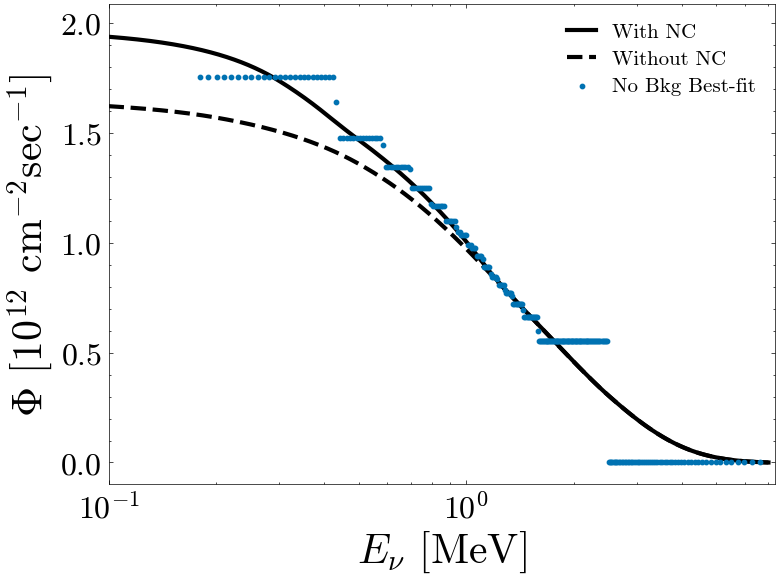

In [9]:
xg = np.logspace(-2, np.log10(7.0), 4000)
ys = np.interp(xg, a.fig1Solid['MeV'], a.fig1Solid['cm**-2sec-1MeV-1'])
yd = np.interp(xg, a.fig1dashed['MeV'], a.fig1dashed['cm**-2sec-1MeV-1'])
Phi_s = np.array([integrate.trapezoid(ys[i:], xg[i:]) for i in range(len(xg))])
Phi_d = np.array([integrate.trapezoid(yd[i:], xg[i:]) for i in range(len(xg))])

norm = 1e12
plt.style.use(os.path.join(REPO, '1eV', 'physrev.mplstyle'))
plt.figure(figsize=(8, 6))
plt.plot(xg, Phi_s/norm, color='black', lw=3, label='With NC')
plt.plot(xg, Phi_d/norm, color='black', lw=3, ls='dashed', label='Without NC')
plt.scatter(edges[:-1], x_fit*conv/norm, s=10, marker='o', color='#0072B2',
            zorder=5, label='No Bkg Best-fit')
plt.xscale('log'); plt.xlim(1e-1, 7.3)
plt.xlabel(r"$E_\nu$ [MeV]", fontsize=30)
plt.ylabel(r"$\Phi$ [$10^{12}$ cm$^{-2}$sec$^{-1}$]", fontsize=30)
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1., 10)*0.1, numticks=20))
plt.tick_params(axis='both', which='both', labelsize=23)
plt.legend(loc='upper right', fontsize=15, frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(HERE, 'results', f'method1_bestfit_{THR}.pdf'))
plt.savefig(os.path.join(HERE, 'results', f'method1_bestfit_{THR}.png'), dpi=115)
plt.show()